# EDA: Predicting AI Exposure by FIPS Code from Demographic Data

## Background & issue statement

Can we predict an area's AI exposure score using only census-derived demographic characteristics of that FIPS code? Policymakers, economists, and workforce planners need to anticipate which communities face the greatest potential disruption -- or opportunity -- from AI-assisted work. The Social Explorer AI Exposure Index scores local labor markets based on their occupational mix and how applicable generative AI is to those occupations. Because fine-grained occupational data can be noisy, lagged, or unavailable for small geographies, a demographic-based predictor could enable more timely and granular estimates.

Our dataset merges two sources:
- **Social Explorer AI Exposure Index**: `AI Exposure Score (0-0.29)` by FIPS, at the census tract levels
- **Census/ACS demographic data**: 1,000+ columns spanning education, employment, occupation, income, housing, commute, and more

The target is `AI Exposure Score (0-0.29)`, which is based off of:

1. **Tomlinson et al. (2025) AI applicability scores** (*"Working with AI: Measuring the Applicability of Generative AI to Occupations"*, Microsoft Research). Rather than predicting what AI could do, Tomlinson et al. analyzed 200,000 real-world, anonymized conversations from Microsoft Bing Copilot (Jan–Sep 2024) and used an LLM-based pipeline to classify each conversation according to the O\*NET Intermediate Work Activities (IWAs) that the AI was assisting with or performing. This produces a data-driven, usage-grounded applicability score for each SOC occupation, measuring how much of an occupation's activity overlaps with tasks people already delegate to generative AI. Occupations involving information work (research, writing, advising, data analysis) score highest; healthcare support, construction, farming, and physical service roles score lowest.

2. **EASI employment-by-place-of-work data**: Occupation-level applicability scores are combined with local employment composition from EASI to produce a weighted composite for each geographic area, then scaled to a 0–100 percentile relative to all areas nationwide.



In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_joined = pd.read_csv("data/joined_cleaned.csv")
ai = pd.read_csv("data/ai.csv")
acs = pd.read_csv("data/acs.csv")
df = pd.read_csv("data/features_0.csv")

/var/folders/cq/s17zvz6n7bzb7tsckr_tzkrw0000gp/T/ipykernel_7357/1765210212.py:6: DtypeWarning: Columns (0: FIPS, 1: AI Exposure Percentile, 2: AI Exposure Score (0-0.29), 3: AI Exposure Score Residence-based Normalized, 4: SE AI Exposure Index, 5: SE AI Exposure Index (Residence-based)) have mixed types. Specify dtype option on import or set low_memory=False.
  ai = pd.read_csv("data/ai.csv")
/var/folders/cq/s17zvz6n7bzb7tsckr_tzkrw0000gp/T/ipykernel_7357/1765210212.py:7: DtypeWarning: Columns (0: FIPS, 1: Area (Land), 2: Area (Water), 3: Total, 4: Total: Male, 5: Total: Male: Management, Business, Science, And Arts Occupations, 6: Total: Male: Management, Business, Science, And Arts Occupations: Management, Business, And Financial Occupations, 7: Total: Male: Management, Business, Science, And Arts Occupations: Management, Business, And Financial Occupations: Management Occupations, 8: Total: Male: Management, Business, Science, And Arts Occupations: Management, Business, And Financia

## Original datasets: AI exposure and ACS


The first raw dataset we brought in was `ai.csv`, which contained AI exposure scores for each census tract in the United States.

In [55]:
ai.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,AI Exposure Percentile,AI Exposure Score (0-0.29),AI Exposure Score Residence-based Normalized,SE AI Exposure Index,SE AI Exposure Index (Residence-based)
0,Geo__geoid_,Geo__geo_level_,Geo_NAME,Geo_qname,ORG_AIEI_001,ORG_AIEI_004,ORG_AIEI_007,ORG_AIEI_030,ORG_AIEI_031
1,01001020100,SL140,Census Tract 201,"Census Tract 201, Autauga County, Alabama",72.19148709322025,0.1916413125837849,0.07129258456723246,114.5977056777569,88.57981536983964
2,01001020200,SL140,Census Tract 202,"Census Tract 202, Autauga County, Alabama",49.38694276947864,0.1764556791915281,0.08639452904681331,105.516997961067,107.343722750211
3,01001020300,SL140,Census Tract 203,"Census Tract 203, Autauga County, Alabama",10.144172106192174,0.14309471480900038,0.08293872621512374,85.56780263417943,103.04994691582598
4,01001020400,SL140,Census Tract 204,"Census Tract 204, Autauga County, Alabama",74.33570658547855,0.1933471843977861,0.07763833749938735,115.61778320399188,96.46430471084264


The second set we brought in was `acs.csv`, which contained over 1,000+ demographic-related features aggregated at the census tract level.

In [56]:
acs.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Total,Total: Male,"Total: Male: Management, Business, Science, And Arts Occupations","Total: Male: Management, Business, Science, And Arts Occupations: Management, Business, And Financial Occupations",...,% Total: 10 To 14 Minutes,% Total: 15 To 19 Minutes,% Total: 20 To 24 Minutes,% Total: 25 To 29 Minutes,% Total: 30 To 34 Minutes,% Total: 35 To 39 Minutes,% Total: 40 To 44 Minutes,% Total: 45 To 59 Minutes,% Total: 60 To 89 Minutes,% Total: 90 Or More Minutes
0,Geo__geoid_,Geo__geo_level_,Geo_NAME,Geo_qname,Geo_AREALAND,Geo_AREAWATER,ORG_C24010001,ORG_C24010002,ORG_C24010003,ORG_C24010004,...,PCT_ORG_B08303004,PCT_ORG_B08303005,PCT_ORG_B08303006,PCT_ORG_B08303007,PCT_ORG_B08303008,PCT_ORG_B08303009,PCT_ORG_B08303010,PCT_ORG_B08303011,PCT_ORG_B08303012,PCT_ORG_B08303013
1,01001020100,SL140,"Census Tract 201, Autauga County, Alabama","Census Tract 201, Autauga County, Alabama",9825303,28435,803,415,129,53,...,21.22,12.58,11.18,15.37,27.06,3.94,2.41,2.29,0.38,0
2,01001020200,SL140,"Census Tract 202, Autauga County, Alabama","Census Tract 202, Autauga County, Alabama",3320818,5669,945,567,272,222,...,10.81,11.72,11.07,5.86,26.43,2.73,7.81,2.86,4.56,0
3,01001020300,SL140,"Census Tract 203, Autauga County, Alabama","Census Tract 203, Autauga County, Alabama",5349271,9054,1630,648,144,123,...,15.12,15.49,14.25,5.7,20.2,2.66,2.11,7.31,2.97,6.44
4,01001020400,SL140,"Census Tract 204, Autauga County, Alabama","Census Tract 204, Autauga County, Alabama",6384282,8408,1674,985,237,151,...,12.41,13.03,14.9,10.04,15.15,3.12,2.56,3.55,0,1.68


Next, we joined these two datasets by FIPS code to generate `joined_cleaned.csv`. However, this dataset contained far too many features to effectively train a model on -- not just due to the sheer number, but also because many of these features were strongly correlated and even bucketed with others. 

For example, this is just a subset of the features related to male employment. Many features, such as `Total: Male: Management, Business, Science, And Arts Occupations: Management, Business, And Financial Occupations`, are subsets of other features like `Total: Male: Management, Business, Science, And Arts Occupations`. 

/var/folders/cq/s17zvz6n7bzb7tsckr_tzkrw0000gp/T/ipykernel_7357/712525240.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


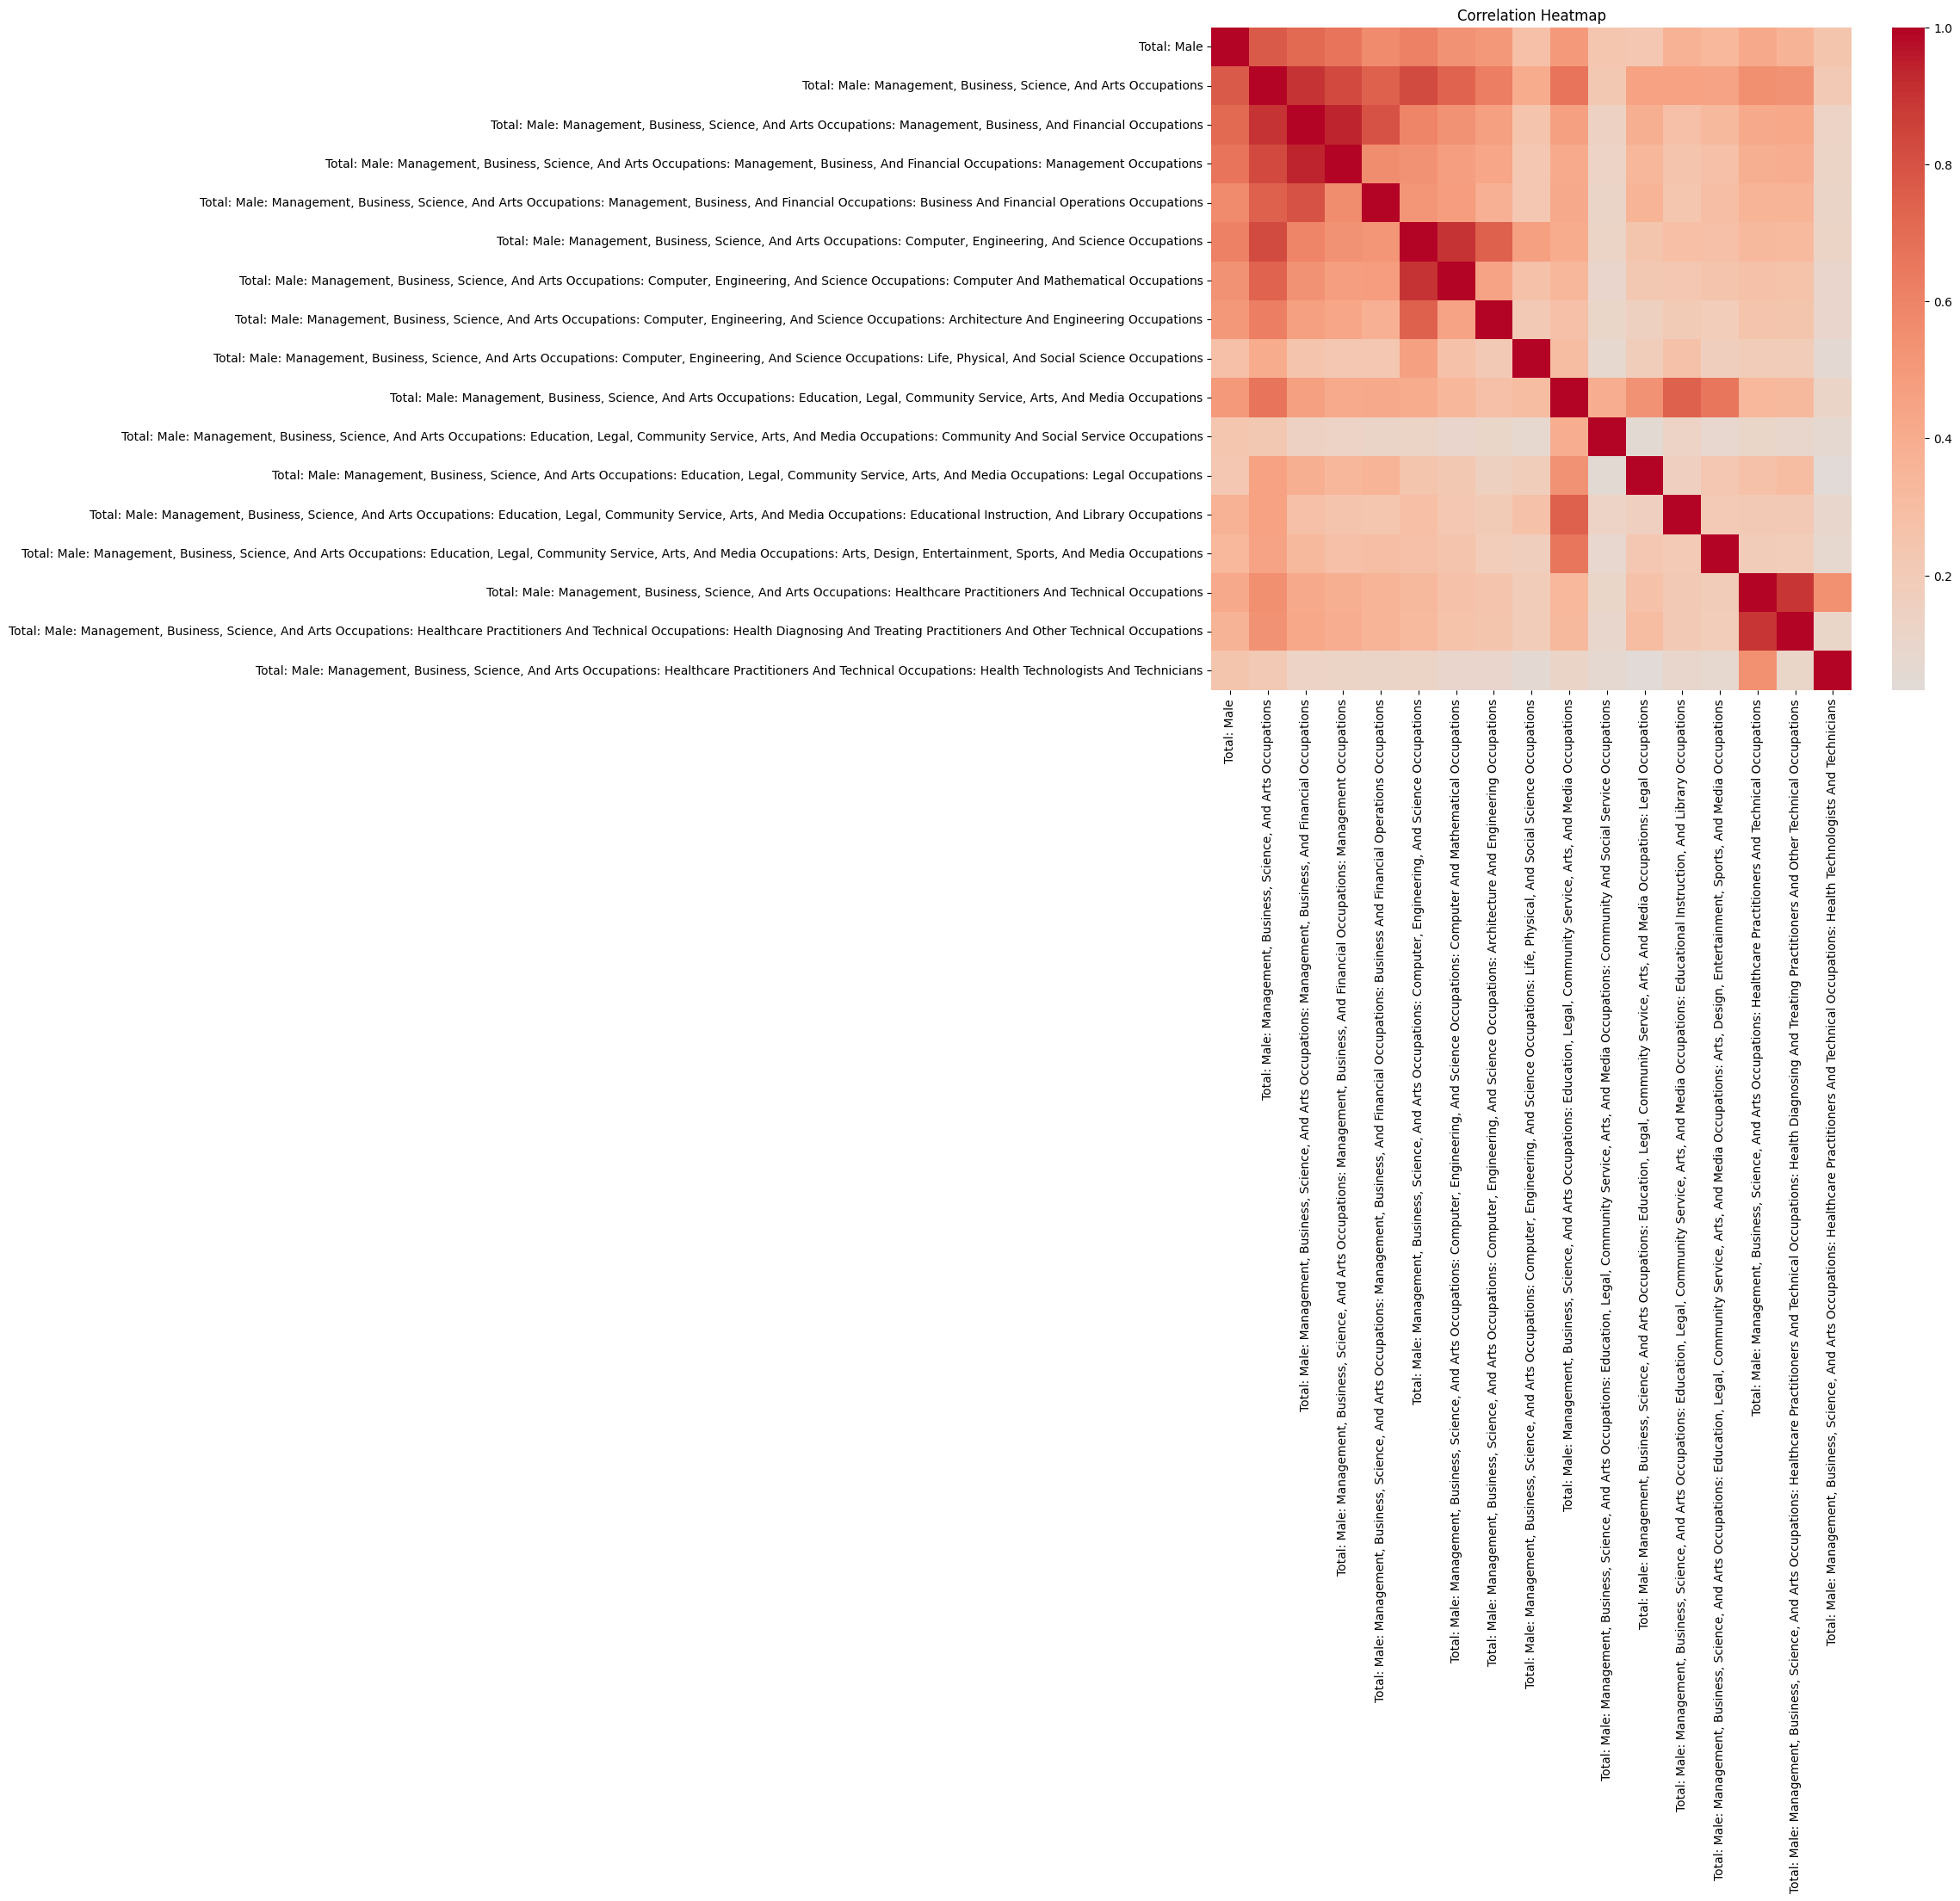

In [57]:
feature_subset = df_joined.iloc[:, 8:25]

feature_subset = feature_subset.select_dtypes(include="number")

corr = feature_subset.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

To address this issue, we cut down the number of features drastically using feature engineering. 

## Feature engineering

Starting from 1,035 raw columns in `joined_cleaned.csv`, we engineered 32 features across 8 categories in `feature_engineering.py` by applying the following reductions:

| Category | Raw columns | Features kept | Approach |
|---|---|---|---|
| Occupation (C24010) | 218 | 4 | Summed male + female; kept 4 of 5 top-level group shares (dropped production/transport as reference) |
| Industry (C24030) | 164 | 12 | Summed male + female; kept 12 of 13 industry shares (dropped other services as reference) |
| Industry × Occupation (C24050) | 251 | 0 | Dropped entirely — redundant with C24010 + C24030 |
| Class of worker (B24080) | 62 | 5 | Summed male + female; combined local/state/federal government into one feature |
| Education (B15003 + B23006) | 111 | 3 | Collapsed 24 grade levels into 3 tiers; dropped B23006 entirely as redundant; dropped less-than-HS as reference |
| Income (B19013 + B19301) | 4 | 2 | Kept median household income and per capita income as-is; dropped standard errors |
| Commute mode + travel time (B08301 + B08303) | 75 | 4 | Kept drove alone, public transit, worked from home; collapsed 12 time bins into one 45+ min share |
| Technology access (B28002 + B28001) | 57 | 2 | One broadband share and one computer ownership share; dropped sub-type breakdowns |

All standard error columns and pre-computed percentage columns were dropped across every table. Raw counts were converted to shares (proportion of the relevant denominator) to ensure comparability across tracts of different sizes.

## Data types, null audit, and summary statistics

In [58]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 82909, Columns: 34


In [59]:
df.head()

,FIPS,AI Exposure Score (0-0.29),pct_mgmt_business_arts,pct_service,pct_sales_office,pct_natural_resources_construction,pct_industry_agriculture,pct_industry_construction,pct_industry_manufacturing,pct_industry_wholesale,...,pct_some_college_assoc,pct_bachelors_plus,median_household_income,per_capita_income,pct_drove_alone,pct_public_transit,pct_worked_from_home,pct_broadband,pct_has_computer,pct_long_commute
0,1001020100,0.191641,0.305106,0.249066,0.231631,0.122042,0.002491,0.057285,0.079701,0.012453,...,0.302185,0.250188,63237,32302,0.860523,0.00000,0.019925,0.974185,0.979620,0.026684
1,1001020200,0.176456,0.378836,0.177778,0.223280,0.035979,0.000000,0.050794,0.082540,0.023280,...,0.202888,0.196390,61229,31064,0.779939,0.00000,0.213920,0.817568,0.920608,0.074219
2,1001020300,0.143095,0.287117,0.085890,0.255828,0.147853,0.000000,0.060736,0.098773,0.080368,...,0.369887,0.121845,63939,27091,0.903695,0.00000,0.022411,0.957085,0.944130,0.167286
3,1001020400,0.193347,0.370968,0.159498,0.254480,0.041219,0.005974,0.051374,0.139785,0.046595,...,0.311244,0.274586,69348,45895,0.849469,0.00000,0.053129,0.950549,0.944444,0.052369
4,1001020501,0.234736,0.454503,0.115599,0.221448,0.090529,0.000000,0.007892,0.113742,0.007892,...,0.222049,0.476487,88965,47982,0.774756,0.00595,0.124947,0.995281,0.995281,0.039825


In [60]:
info_df = pd.DataFrame({
    "data type": df.dtypes,
    "null count": df.isnull().sum(),
    "unique values": df.nunique(),
})
print(info_df.to_string())

                                   data type  null count  unique values
FIPS                                   int64           0          82909
AI Exposure Score (0-0.29)           float64           0          80599
pct_mgmt_business_arts               float64           0          76420
pct_service                          float64           0          72176
pct_sales_office                     float64           0          70634
pct_natural_resources_construction   float64           0          68158
pct_industry_agriculture             float64           0          34855
pct_industry_construction            float64           0          65817
pct_industry_manufacturing           float64           0          69421
pct_industry_wholesale               float64           0          48783
pct_industry_retail                  float64           0          68472
pct_industry_transport_utilities     float64           0          64311
pct_industry_information             float64           0        

## Target variable distribution

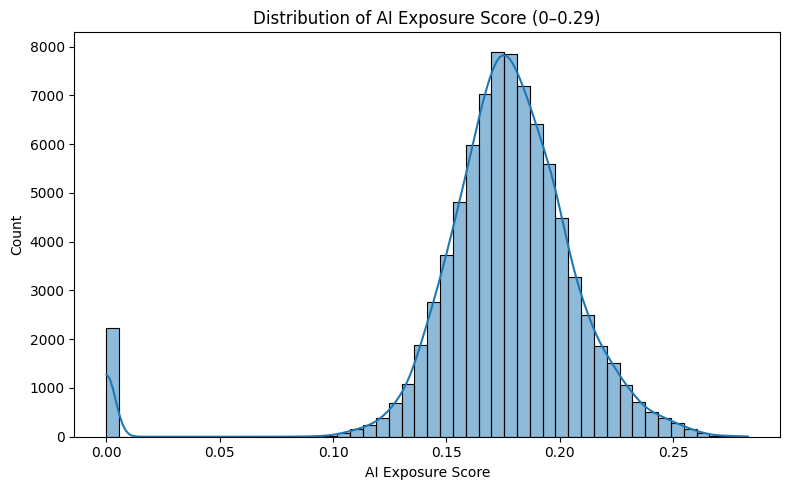

In [61]:
target = "AI Exposure Score (0-0.29)"

plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=50, kde=True)

plt.title("Distribution of AI Exposure Score (0–0.29)")
plt.xlabel("AI Exposure Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

The distribution of AI Exposure Score is approximately unimodal and roughly bell-shaped for positive values, centered around ~0.175. However, there is a significant point mass at zero, indicating a large subset of observations with no measured exposure. We removed these outliers.

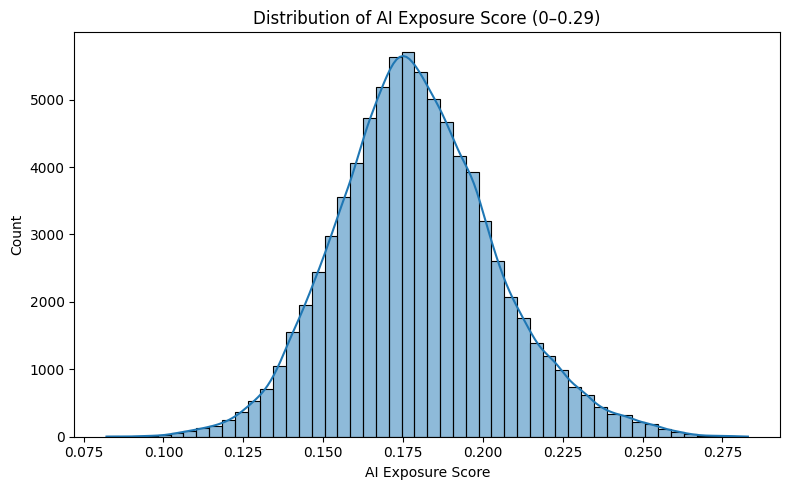

In [62]:
df = pd.read_csv("data/features.csv")
target = "AI Exposure Score (0-0.29)"

plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=50, kde=True)

plt.title("Distribution of AI Exposure Score (0–0.29)")
plt.xlabel("AI Exposure Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()